# Case Study — Iguanas From Above: AI-Assisted Wildlife Census in the Galápagos

> *Winkelmann, C. (2025). Automated detection of marine iguanas from drone imagery using point-based deep learning. HNEE Master Thesis. DOI: [10.6084/m9.figshare.30719999](https://doi.org/10.6084/m9.figshare.30719999)*

This notebook walks through a **real conservation AI project** from start to finish:
counting marine iguanas (*Amblyrhynchus cristatus*) in the Galápagos Islands
using drone imagery and a point-based deep learning detector.

You will see:
- Why traditional monitoring methods fail at scale
- How a full drone-to-model pipeline was designed
- What worked, what failed, and what would you do differently
- How the same tools you used in Practicals 2–8 were applied to a real field problem

**This notebook is read-only** — no coding required, just run each cell top to bottom.


In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# Figures bundled with this notebook (assets/iguana_case_study/)
ASSETS = Path("assets/iguana_case_study")
THESIS_FIGS = ASSETS
THESIS_ROOT = ASSETS

def show_img(path, title=None, figsize=(10, 6)):
    path = Path(path)
    if not path.exists():
        print(f"[figure not found: {path}]")
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(np.array(Image.open(path)))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

print("Setup complete.")


Setup complete.


---
## 1 — Why Count Marine Iguanas?

Marine iguanas are the **world's only marine-foraging lizard** and exist
nowhere else on Earth. The Galápagos archipelago hosts 11 recognized
subspecies — several with critically small or unknown populations.

**The monitoring problem:**

| Method | Limitation |
|--------|-----------|
| Aircraft surveys | 30% observer bias; expensive; stress to animals |
| Manual photo counting | Annotator fatigue; inconsistent across sessions |
| Ground transects | Rugged volcanic terrain blocks access to major colonies |
| Citizen science | Zooniverse counts show 15–30% discrepancy vs experts |

No reliable census data exists for most populations.
Some subspecies show steep declines — but nobody knows exactly how steep.

**The drone solution:** Nadir (straight-down) drone surveys at 22–27 m altitude
produce orthomosaics at ~3 mm/pixel resolution. Every iguana is visible.
The bottleneck is annotation — a single flight produces thousands of tiles
that need to be counted.


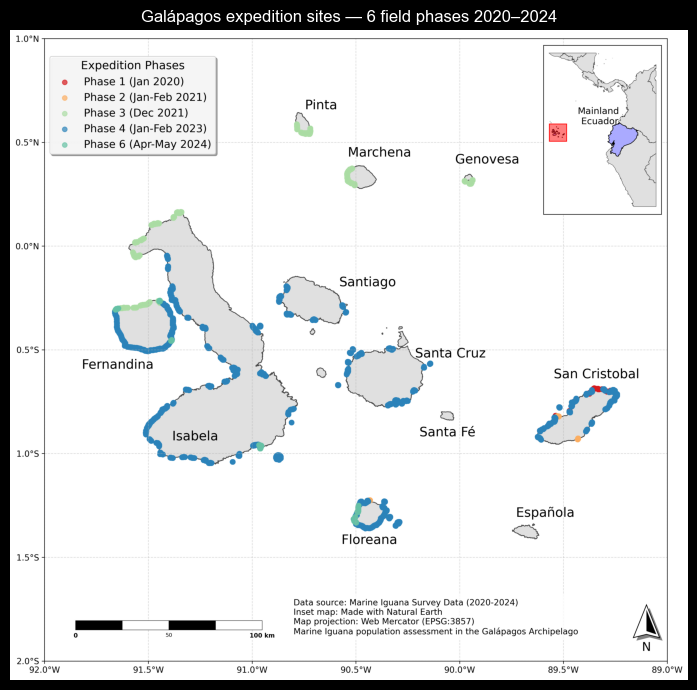

In [2]:
show_img(
    THESIS_FIGS / "maps" / "galapagos_expedition_map.png",
    title="Galápagos expedition sites — 6 field phases 2020–2024",
    figsize=(12, 7),
)


---
## 2 — The Pipeline: Drone → Model → Census

```
Field expedition
      │
      ▼
Drone survey (DJI, 22–27m altitude, nadir)
      │
      ▼
Orthomosaic stitching (Pix4D — better than DroneDeploy, as we'll see)
      │
      ▼
Tile extraction (512×512 px crops, ~3 mm/px GSD)
      │
      ▼
Point annotation (body-center click per iguana in Hasty.ai)
      │
      ▼
HerdNet training (point → FIDT density map → DLA-34 detector)
      │
      ▼
HITL correction (expert reviews predictions, fixes errors)
      │
      ▼
Island census count
```

Five islands, six field phases (2020–2024):
**Floreana · Fernandina · Genovesa · Isabela · San Cristóbal**

Each island is its own challenge: different iguana colouring, different
volcanic rock texture, different colony density.


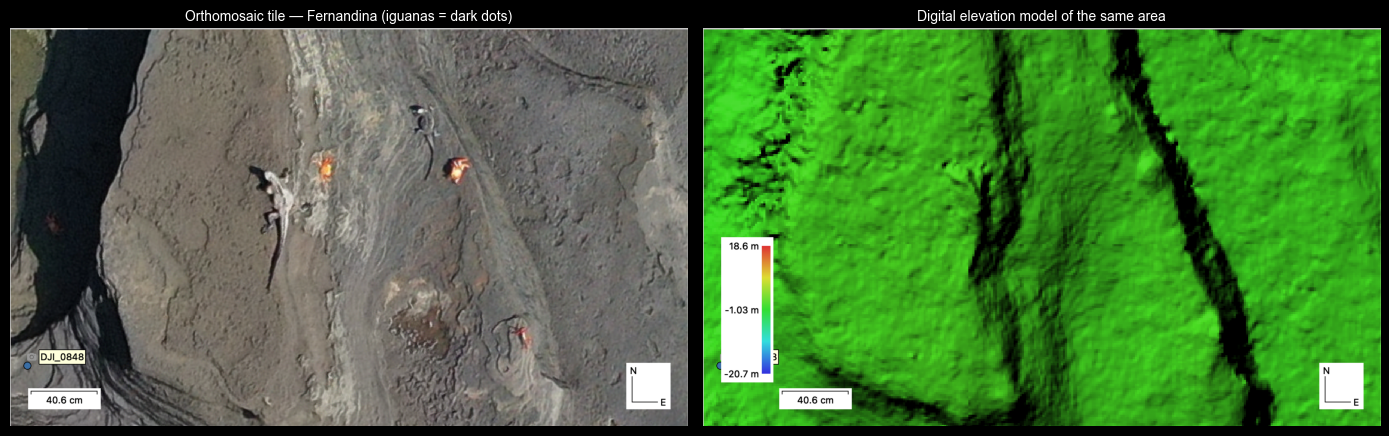

In [3]:
# High-resolution drone image and the orthomosaic DEM slice
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fname, title in [
    (axes[0], THESIS_FIGS / "maps" / "HighResolutionSlice_Ortho.png",
     "Orthomosaic tile — Fernandina (iguanas = dark dots)"),
    (axes[1], THESIS_FIGS / "maps" / "HighResolutionSlice_DEM.png",
     "Digital elevation model of the same area"),
]:
    p = Path(fname)
    if p.exists():
        ax.imshow(np.array(Image.open(p)))
    ax.axis("off")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()


In [4]:
# TODO can you add more examples of igaunas?

---
## 3 — The Detection Challenge

Look closely at the orthomosaic tiles. Iguanas are:

- **5–30 px across** in a 512×512 tile (≈ 0.01–0.3% of the tile area)
- **Camouflaged** — dark grey on dark volcanic rock (especially Fernandina)
- **Aggregated** — colonies of hundreds of animals, bodies overlapping
- **Variable** — different postures, lighting, shadow patterns per island

This is why bounding-box detectors (YOLOv8, MegaDetector) struggle:
boxes overlap so heavily in dense colonies that NMS suppresses real detections.

**Point-based detection** (HerdNet) predicts a density heatmap — one peak
per animal center — and avoids the overlap problem entirely.


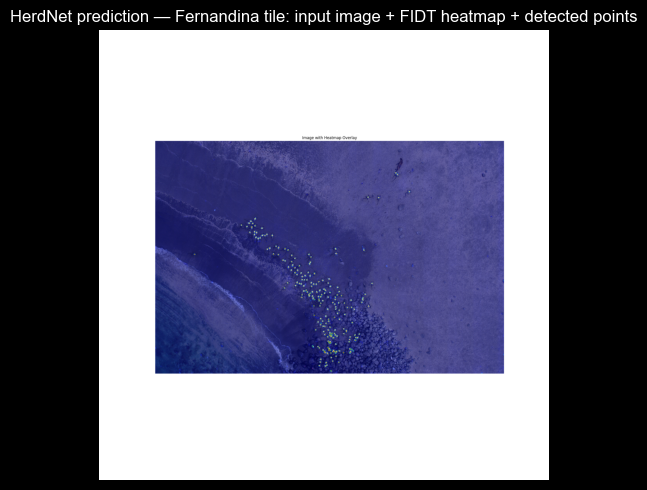

In [5]:
show_img(
    THESIS_ROOT / "detection_examples" /
    "Fer_FCD01-02-03_20122021_single_images___DJI_0677.JPG_75_heatmap.png_51685_bd77c36a8f7b354e0614.png",
    title="HerdNet prediction — Fernandina tile: input image + FIDT heatmap + detected points",
    figsize=(14, 5),
)


---
## 4 — Annotation Quality Matters More Than Quantity

**Finding 1: Body-center beats head annotations**

Two biologists annotated the same images differently:
- Group A clicked the **head** of each iguana
- Group B clicked the **body center**

| Annotation type | Orthomosaic software | F1 score |
|----------------|---------------------|---------|
| Head | DroneDeploy | 0.68 |
| Body center | DroneDeploy | 0.78 |
| Body center | Pix4D | **0.85** |

**+0.17 F1 from annotation placement alone.** HerdNet learns to find
the center-of-mass feature in the FIDT heatmap — heads shift with posture,
body centers don't.

**Finding 2: Learning curves plateau early**

More annotations have diminishing returns. Performance on Floreana saturates
at ~950 annotations; Fernandina at ~3 100. After that, annotation *quality*
(not quantity) is the bottleneck. This mirrors Nakkiran et al. (2021) on
label noise sensitivity — ~30% annotation noise made larger models overfit.


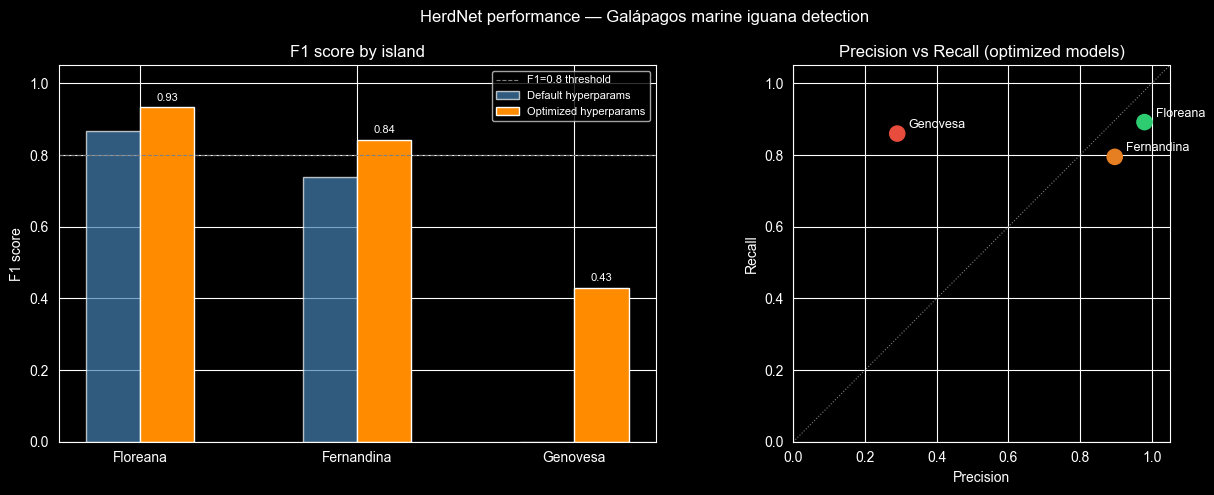

Genovesa caveat: F1=0.43 but Recall=0.86 — the model finds most iguanas
but Precision=0.29 means 71% of predictions are false positives.
Genovesa iguanas are pitch-black on black rock with extreme crowding.


In [6]:
# Final model performance across islands
islands   = ["Floreana", "Fernandina", "Genovesa"]
f1_default = [0.867,     0.739,        None]
f1_optimized = [0.934,   0.843,        0.430]
precision = [0.980,      0.897,        0.290]
recall    = [0.892,      0.795,        0.860]

x = np.arange(len(islands))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 comparison
ax = axes[0]
bars_def = ax.bar(x - width/2, [v or 0 for v in f1_default],
                  width, label="Default hyperparams", color="steelblue", alpha=0.7)
bars_opt = ax.bar(x + width/2, f1_optimized,
                  width, label="Optimized hyperparams", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(islands)
ax.set_ylim(0, 1.05); ax.set_ylabel("F1 score")
ax.set_title("F1 score by island")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, label="F1=0.8 threshold")
ax.bar_label(bars_opt, fmt="%.2f", padding=3, fontsize=8)
ax.legend(fontsize=8)

# Precision vs Recall (optimized)
ax = axes[1]
ax.scatter(precision, recall, s=120, zorder=3,
           color=["#2ecc71", "#e67e22", "#e74c3c"])
for i, island in enumerate(islands):
    ax.annotate(island, (precision[i], recall[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
ax.set_title("Precision vs Recall (optimized models)")
ax.axline((0, 0), slope=1, color="gray", linestyle=":", linewidth=0.8)
ax.set_aspect("equal")

plt.suptitle("HerdNet performance — Galápagos marine iguana detection", fontsize=12)
plt.tight_layout()
plt.show()

print("Genovesa caveat: F1=0.43 but Recall=0.86 — the model finds most iguanas")
print("but Precision=0.29 means 71% of predictions are false positives.")
print("Genovesa iguanas are pitch-black on black rock with extreme crowding.")


---
## 5 — Cross-Island Generalization Fails

A natural question: can a model trained on Fernandina detect iguanas on Genovesa?

**Answer: No — and this is an important lesson.**

Each island has distinct:
- Iguana colouring (reddish Floreana, grey Fernandina, black Genovesa)
- Volcanic rock texture and colour
- Colony density and spatial distribution

Training on mixed-island data **degraded** per-island F1 compared to
island-specific models. The visual heterogeneity was too large.

**Practical implication:** For deployment, you need either:
1. Island-specific models (highest performance, most annotation work)
2. A large pan-island dataset (~10× current size) to force generalization
3. Domain adaptation techniques (not yet tested)

This is the core trade-off in any wildlife AI deployment:
**generality vs. specificity**.


---
## 6 — Human-in-the-Loop (HITL): Closing the Loop

After training, the model predicted on the full Fernandina orthomosaic.
An expert then *reviewed* the predictions rather than annotating from scratch.

**Fernandina HITL results:**
- Initial manual count: **12,475** iguanas
- AI prediction: **9,265** (26% undercount — mostly missed dense aggregations)
- After HITL correction: **11,506**

Surprise finding: the manual count **overcounted by ~8%** in the densest
breeding colonies (where bodies stack). The AI+HITL combination was more
reliable than manual counting alone.

**Annotation throughput:**
- Pure manual: ~50–100 annotations/hour (estimated, reference dense tiles)
- HITL correction: **~330 annotations/hour** (3–6× faster)

35 hours of HITL work processed ~11,500 predictions.


The Iguanas from Above online Correction tool is CVAT

[CVAT Corrections](https://app.cvat.ai/projects?page=1&pageSize=12)

In [7]:
from IPython.display import display

pdf_path = THESIS_ROOT / "MasterThesisOverview-HumanInTheLoop.drawio.pdf"

if pdf_path.exists():
    try:
        import fitz  # PyMuPDF
        doc = fitz.open(str(pdf_path))
        page = doc[0]
        pix = page.get_pixmap(dpi=150)
        from IPython.display import Image as IPImage
        display(IPImage(data=pix.tobytes("png")))
    except ImportError:
        print("Install PyMuPDF for inline rendering: pip install pymupdf")
        from IPython.display import FileLink
        display(FileLink(str(pdf_path)))
else:
    print(f"[figure not found: {pdf_path}]")


Install PyMuPDF for inline rendering: pip install pymupdf


/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/assets/iguana_case_study/MasterThesisOverview-HumanInTheLoop.drawio.pdf

---
## 7 — Image Quality Is the Real Bottleneck

The single biggest performance driver was **not** model architecture or
hyperparameters — it was **orthomosaic software**:

| Factor | Effect on F1 |
|--------|-------------|
| Pix4D vs DroneDeploy (body markers) | **+0.17 F1** |
| Body-center vs head annotation | +0.10 F1 |
| Hyperparameter optimization | +0.06–0.10 F1 |
| DLA-34 vs larger DLA variants | +0.02–0.04 F1 |

Pix4D produced sharper orthomosaics with less ghosting artifact than DroneDeploy.
That sharpness gave the model cleaner texture to learn from.

**Lesson:** Before spending weeks on model tuning, spend a day improving your
data pipeline. Garbage in, garbage out — at every stage.


---
## 8 — Experts Are Also Imperfect

A critical validation step: what counts as "ground truth"?

Four expert biologists annotated the same 496 images independently.
They disagreed — measurably:

| Metric | Range across 4 experts |
|--------|----------------------|
| Precision (vs consensus) | 0.869 – 0.911 |
| Recall (vs consensus) | 0.895 – 0.964 |
| MAE per image | 0.056 – 0.169 animals |

**Consensus = 1,014 iguanas** from individual counts of 1,042–1,098.

The best model (Floreana optimized, F1=0.93) falls *within* the range of
human inter-annotator agreement. This matters:

> **"Better than human" is not a meaningful bar when humans disagree by 5–10%.**

What we actually need is a model that is *consistent* and *fast*, not perfect.
A model that counts 1,000 images in 10 minutes with ±5% error is enormously
more valuable for long-term monitoring than a human who counts 10 images
per hour with ±8% error.


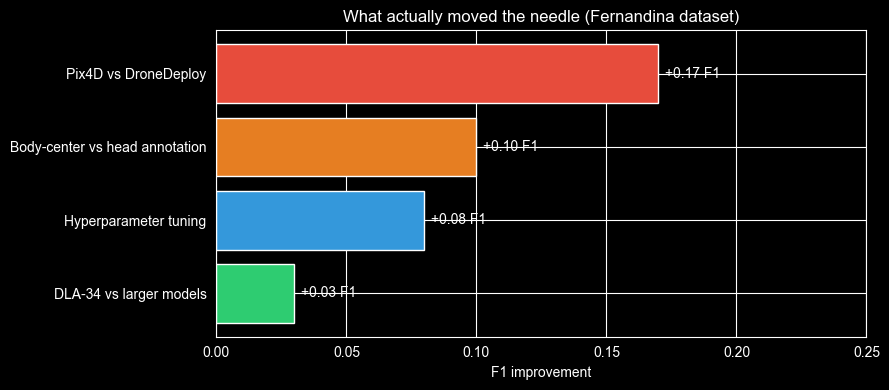

In [8]:
# Summary: what drove performance improvements
factors = [
    "Pix4D vs DroneDeploy",
    "Body-center vs head annotation",
    "Hyperparameter tuning",
    "DLA-34 vs larger models",
]
delta_f1 = [0.17, 0.10, 0.08, 0.03]
colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(factors, delta_f1, color=colors)
ax.bar_label(bars, fmt="+%.2f F1", padding=5)
ax.set_xlim(0, 0.25)
ax.set_xlabel("F1 improvement")
ax.set_title("What actually moved the needle (Fernandina dataset)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---
## 9 — Connecting to the Course Practicals

Every tool you used in this module appeared in this case study:

| Practical | Tool used in Iguanas From Above |
|-----------|--------------------------------|
| P2 — MegaDetector | Used for initial species verification; not the final detector |
| P4 — Label Studio | Annotation review workflow (similar to Hasty.ai used in study) |
| P5 — SpeciesNet | Species confirmation of crops before annotation |
| P6 — Domain shift | Cross-island failure is a domain shift problem |
| P6 — AerialDetector | HerdNet is the point-detection equivalent for aerial imagery |
| P7 — Fine-tuning | Per-island model training from transfer learning |
| P8 — Segmentation | Used for habitat classification in study area analysis |

The iguana project is **not a finished product** — it is an ongoing research
tool with known limitations (Genovesa, cross-island generalization, image quality
dependence). Real conservation AI is always a work in progress.


---
## Exercises

1. **Annotation design decision** — You are setting up a new species survey
   (e.g., seabird colony on a clifftop). Would you annotate head or body center?
   What would you test first, and why?

2. **Failure mode analysis** — The Genovesa model has Precision=0.29 but
   Recall=0.86. For a conservation census, which matters more — that you find
   most animals (high recall) or that your detections are mostly correct
   (high precision)? Justify your answer.

3. **Dataset design** — You have a budget for 2 000 annotations.
   The learning curves suggest Floreana saturates at ~950.
   Would you annotate 2 000 images on one island, or 1 000 on two islands?
   What does the cross-island failure finding suggest?

4. **HITL budget** — An annotator can correct 330 predictions/hour.
   Your model predicts 50 000 tiles. Assuming 20% of predictions need
   correction, how many annotation-hours does HITL require?
   How does this compare to annotating from scratch at 50 annotations/hour?

5. **Image quality experiment** — The thesis showed Pix4D > DroneDeploy
   (+0.17 F1). Design a controlled experiment to test whether a third
   software (e.g., OpenDroneMap) would outperform both. What would your
   evaluation metric be?


## Reflection

- **On ground truth**: No true ground truth exists for wildlife counts.
  Even experts disagree by 5–10%. How should we report model performance
  when the "gold standard" is itself uncertain?

- **On transfer learning**: The model was initialised from ImageNet features
  and fine-tuned on 512-px iguana tiles. What features do you think it learned?
  (Hint: texture? colour contrast? silhouette shape?)

- **On deployment**: The Fernandina HITL result showed the AI+human combination
  was *more accurate* than pure human counting. At what point would you trust
  the AI enough to reduce the human review step?

- **On scale**: The full Fernandina orthomosaic is hundreds of square kilometers and hundreds of Gigabytes. A human would
  spend weeks counting it. The model processes it in hours. This is the
  core value proposition of conservation AI — not perfection, but **scale**.


